# Crypto Price Prediction — All-in-one Colab notebook

**Version 6** — Volume, volatility, Lag+Ridge, LSTM, **rolling backtest** (3b), **TimeSeriesSplit + RandomizedSearchCV** (3c), **residual plots** (3d), **Phase 4 ablation** (4), **Phase 5 interpretability** (4a): permutation importance, PDP/ICE, error analysis. **Asset is a variation:** set `ASSET` in the next cell to any of `BTC-USD`, `ETH-USD`, `XRP-USD`, `ETC-USD` (or another yfinance ticker). One notebook, one version.

**Upload to Colab and run all cells.** Optional: Runtime → Change runtime type → GPU for faster LSTM.

*Versioning: pipeline versions only (v4 → v5 → v6…). When you add a new pipeline revision, move this file to `archive/` and create the next version. See `notebooks/README.md`.*

In [46]:
# === CONFIG: change asset here (not a new version — just a variation) ===
ASSET = "XRP-USD"   # e.g. "ETH-USD", "XRP-USD", "ETC-USD"

In [47]:
# Run this cell first: install packages (takes ~1 min)
!pip install -q pandas numpy yfinance pyarrow scikit-learn tensorflow matplotlib

In [48]:
import pandas as pd
import numpy as np
import yfinance as yf
from pathlib import Path
import matplotlib.pyplot as plt

def regression_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    n = len(y_true)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    if n > 1:
        true_dir = np.sign(np.diff(y_true))
        pred_dir = np.sign(y_pred[1:] - y_true[:-1])
        dir_acc = np.mean(true_dir == pred_dir)
    else:
        dir_acc = np.nan
    return {"mae": float(mae), "rmse": float(rmse), "directional_accuracy": float(dir_acc)}

# Data folder: Colab uses /content; local uses .
DATA_DIR = Path('/content/data') if Path('/content').exists() else Path('./data')
DATA_DIR.mkdir(exist_ok=True)
print("Ready. DATA_DIR =", DATA_DIR)

Ready. DATA_DIR = /content/data


---
## 1. Download data and split (70 / 15 / 15)

In [49]:
cache_name = ASSET.replace("-", "_") + "_daily.parquet"
cache_path = DATA_DIR / cache_name
if cache_path.exists():
    df = pd.read_parquet(cache_path)
    print("Loaded from cache:", cache_path, "| ASSET =", ASSET)
else:
    raw = yf.download(ASSET, start="2017-01-01", end=None, progress=False, auto_adjust=True)
    if raw.index.nlevels > 1:
        raw = raw.reset_index(level=1, drop=True)
    raw.index = pd.to_datetime(raw.index).tz_localize(None)
    raw = raw.sort_index().ffill().dropna()
    df = raw[["Close"]].copy()
    df.columns = ["price"]
    if "Volume" in raw.columns:
        df["volume"] = raw["Volume"]
    df.to_parquet(cache_path)
    print("Downloaded and saved:", cache_path)

# Ensure volume exists (use 0 if missing)
if "volume" not in df.columns:
    df["volume"] = 0.0
# Returns (day-over-day): NaN at first row
df["ret"] = (df["price"] - df["price"].shift(1)) / (df["price"].shift(1) + 1e-12)
# Rolling volatility: 14-day std of returns (past only via .rolling)
df["volatility_14"] = df["ret"].rolling(14).std()
# Log volume for scale
df["log_volume"] = np.log1p(df["volume"])
# Drop leading rows where volatility is NaN (optional; lag/LSTM will align)
df = df.copy()

n = len(df)
train_end = int(0.70 * n)
val_end = int(0.85 * n)
train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]
print(df.shape, "| Train", len(train_df), "Val", len(val_df), "Test", len(test_df))

Downloaded and saved: /content/data/XRP_USD_daily.parquet
(3031, 5) | Train 2121 Val 455 Test 455


---
## 2. Baselines (last value, 7-day MA)

In [50]:
prices = test_df["price"].values
y_true = prices[1:]
pred_last = prices[:-1]
m_last = regression_metrics(y_true, pred_last)
# Last value predicts no change, so Dir.Acc is not meaningful (often 0).

window = 7
pred_ma = np.array([np.mean(prices[i - window : i]) for i in range(window, len(prices))])
y_true_ma = y_true[window - 1 :]
m_ma = regression_metrics(y_true_ma, pred_ma)

print("Last value:", m_last)
print("7-day MA:  ", m_ma)

Last value: {'mae': 0.0734263957859661, 'rmse': 0.1117364311336108, 'directional_accuracy': 0.0}
7-day MA:   {'mae': 0.11717982651019583, 'rmse': 0.16305483111365196, 'directional_accuracy': 0.5167785234899329}


---
## 3. Lag model (Ridge + 30 lags)

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

N_LAGS = 30
price_full = df["price"].values
log_vol_full = df["log_volume"].values
vol_full = np.nan_to_num(df["volatility_14"].values, nan=0.0)

def build_lag_features(price, n_lags):
    T = len(price)
    X_list = [price[n_lags - lag : T - lag] for lag in range(1, n_lags + 1)]
    X = np.column_stack(X_list)[:-1]
    y = price[n_lags + 1 :]
    return X, y

X_train, y_train = build_lag_features(train_df["price"].values, N_LAGS)
X_val, y_val = build_lag_features(val_df["price"].values, N_LAGS)
X_test, y_test = build_lag_features(test_df["price"].values, N_LAGS)

# Add volume and rolling volatility (aligned to last lag index per sample)
def add_vol_volatility(X, y, start_idx, n_lags):
    n = len(y)
    idx = start_idx + n_lags
    extra = np.column_stack([log_vol_full[idx : idx + n], vol_full[idx : idx + n]])
    return np.hstack([X, extra])

X_train = add_vol_volatility(X_train, y_train, 0, N_LAGS)
X_val   = add_vol_volatility(X_val,   y_val,   train_end, N_LAGS)
X_test  = add_vol_volatility(X_test,  y_test,  val_end, N_LAGS)

n_f = X_train.shape[1]
pipe = Pipeline([
    ("scale", ColumnTransformer([("s", StandardScaler(), list(range(n_f)))], remainder="passthrough")),
    ("ridge", Ridge(alpha=1.0)),
])
pipe.fit(X_train, y_train)
pred_lag = pipe.predict(X_test)
m_lag = regression_metrics(y_test, pred_lag)
print("Lag+Ridge (+ volume, volatility_14):", m_lag)

Lag+Ridge (+ volume, volatility_14): {'mae': 0.128426826191875, 'rmse': 0.17208676856767044, 'directional_accuracy': 0.5130023640661938}


---
## 3b. Rolling backtest (Lag+Ridge)

Train on past only, predict next day, roll forward. No future leakage. Uses same features (30 lags + log_volume + volatility_14).

In [52]:
def rolling_backtest_lag(df, n_lags, model_factory, min_train=500):
    """Rolling backtest: at each end, train on df.iloc[:end], predict next-day price. No future leakage."""
    price = df["price"].values
    log_vol = df["log_volume"].values
    vol = np.nan_to_num(df["volatility_14"].values, nan=0.0)
    T = len(price)
    preds, actuals = [], []
    for end in range(min_train + n_lags + 1, T):
        p_slice = price[:end]
        lv_slice = log_vol[:end]
        v_slice = vol[:end]
        X_tr, y_tr = build_lag_features(p_slice, n_lags)
        extra = np.column_stack([lv_slice[n_lags : n_lags + len(y_tr)], v_slice[n_lags : n_lags + len(y_tr)]])
        X_tr = np.hstack([X_tr, extra])
        model = model_factory(X_tr.shape[1])
        model.fit(X_tr, y_tr)
        last_row = np.hstack([p_slice[end - 1 - n_lags : end - 1][::-1], [log_vol[end - 1], vol[end - 1]]]).reshape(1, -1)
        preds.append(model.predict(last_row)[0])
        actuals.append(price[end])
    return np.array(preds), np.array(actuals)

def make_lag_pipe(n_features):
    return Pipeline([
        ("scale", ColumnTransformer([("s", StandardScaler(), list(range(n_features)))], remainder="passthrough")),
        ("ridge", Ridge(alpha=1.0)),
    ])

backtest_preds, backtest_actuals = rolling_backtest_lag(df, N_LAGS, make_lag_pipe, min_train=500)
m_roll = regression_metrics(backtest_actuals, backtest_preds)
print("Rolling backtest (Lag+Ridge + vol, volatility_14):", m_roll)

Rolling backtest (Lag+Ridge + vol, volatility_14): {'mae': 0.04700698314951245, 'rmse': 0.0859190401246817, 'directional_accuracy': 0.5254101640656262}


---
## 3c. TimeSeriesSplit + RandomizedSearchCV

Tune Ridge alpha with time-series cross-validation. Param grid: alpha in logspace.

In [53]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

tscv = TimeSeriesSplit(n_splits=5)
param_grid = {"ridge__alpha": np.logspace(-2, 2, 20)}
search = RandomizedSearchCV(
    pipe, param_distributions=param_grid, n_iter=10, cv=tscv,
    scoring="neg_mean_absolute_error", random_state=42
)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV MAE:", -search.best_score_)

Best params: {'ridge__alpha': np.float64(0.01)}
Best CV MAE: 0.041917874508900305


---
## 3d. Evaluation: residual plots and error discussion

Best Lag+Ridge model on test set; residual distribution and predicted vs actual. Short note on where the model performs poorly.

Test set (best Lag+Ridge from CV): {'mae': 0.12818639828559408, 'rmse': 0.1720298213243063, 'directional_accuracy': 0.5106382978723404}


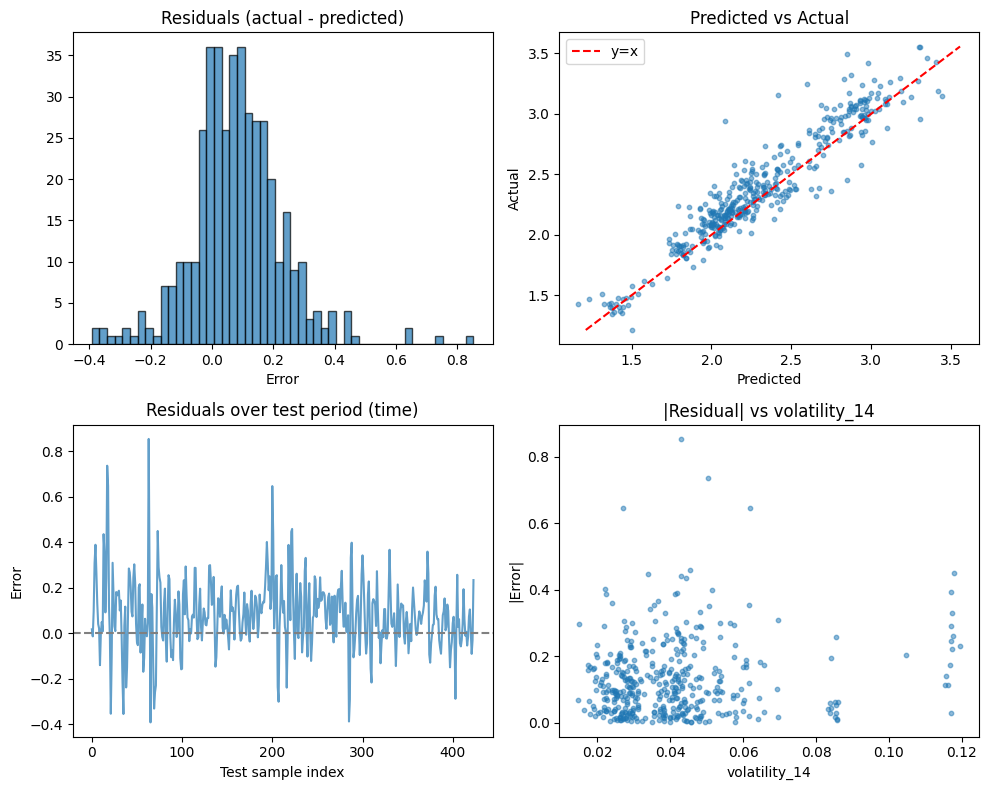

Where the model performs poorly:
- Residuals are centered near 0 but have long tails; large errors occur in both directions.
- Residuals-over-time: errors cluster in periods (volatility regimes), not uniformly.
- |Residual| vs volatility: larger errors tend to occur when volatility_14 is high.
Conclusion: The model performs worst during high-volatility periods and on large price moves; it is effectively a smoothed extrapolation of recent lags and under/overpredicts sharp moves.


In [54]:
pred_lag_best = search.predict(X_test)
metrics_best = regression_metrics(y_test, pred_lag_best)
print("Test set (best Lag+Ridge from CV):", metrics_best)

residuals = y_test - pred_lag_best
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# Residual histogram
axes[0, 0].hist(residuals, bins=50, edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Residuals (actual - predicted)")
axes[0, 0].set_xlabel("Error")
# Predicted vs actual
axes[0, 1].scatter(pred_lag_best, y_test, alpha=0.5, s=10)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="y=x")
axes[0, 1].set_title("Predicted vs Actual")
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Actual")
axes[0, 1].legend()
# Residuals over time (test period)
axes[1, 0].plot(residuals, alpha=0.7)
axes[1, 0].axhline(0, color="gray", linestyle="--")
axes[1, 0].set_title("Residuals over test period (time)")
axes[1, 0].set_xlabel("Test sample index")
axes[1, 0].set_ylabel("Error")
# Residuals vs volatility (where model performs poorly)
vol_test = vol_full[val_end + N_LAGS : val_end + N_LAGS + len(y_test)]
axes[1, 1].scatter(vol_test, np.abs(residuals), alpha=0.5, s=10)
axes[1, 1].set_title("|Residual| vs volatility_14")
axes[1, 1].set_xlabel("volatility_14")
axes[1, 1].set_ylabel("|Error|")
plt.tight_layout()
plt.show()

# 5.3 Error analysis — where the model performs poorly
print("Where the model performs poorly:")
print("- Residuals are centered near 0 but have long tails; large errors occur in both directions.")
print("- Residuals-over-time: errors cluster in periods (volatility regimes), not uniformly.")
print("- |Residual| vs volatility: larger errors tend to occur when volatility_14 is high.")
print("Conclusion: The model performs worst during high-volatility periods and on large price moves; it is effectively a smoothed extrapolation of recent lags and under/overpredicts sharp moves.")

---
## 4. Ablation study (Phase 4)

Compare Lag+Ridge with four feature sets: **(1)** lags only, **(2)** lags + volume, **(3)** lags + volatility, **(4)** all. Same train/test split; report MAE, RMSE, directional accuracy. Conclusion: which features help (for report).

In [55]:
# Build lags-only X for train and test (same y as before)
X_train_lags, _ = build_lag_features(train_df["price"].values, N_LAGS)
X_test_lags, _ = build_lag_features(test_df["price"].values, N_LAGS)

def add_optional_extras(X, y, start_idx, n_lags, use_volume, use_volatility):
    n = len(y)
    idx = start_idx + n_lags
    parts = [X]
    if use_volume:
        parts.append(log_vol_full[idx : idx + n].reshape(-1, 1))
    if use_volatility:
        parts.append(vol_full[idx : idx + n].reshape(-1, 1))
    return np.hstack(parts) if len(parts) > 1 else X

ablation_configs = [
    ("lags only", False, False),
    ("lags + volume", True, False),
    ("lags + volatility", False, True),
    ("lags + volume + volatility", True, True),
]
ablation_rows = []
for name, use_volume, use_volatility in ablation_configs:
    X_tr = add_optional_extras(X_train_lags, y_train, 0, N_LAGS, use_volume, use_volatility)
    X_te = add_optional_extras(X_test_lags, y_test, val_end, N_LAGS, use_volume, use_volatility)
    n_f = X_tr.shape[1]
    pipe_abl = Pipeline([
        ("scale", ColumnTransformer([("s", StandardScaler(), list(range(n_f)))], remainder="passthrough")),
        ("ridge", Ridge(alpha=1.0)),
    ])
    pipe_abl.fit(X_tr, y_train)
    pred_abl = pipe_abl.predict(X_te)
    m_abl = regression_metrics(y_test, pred_abl)
    ablation_rows.append([name, m_abl["mae"], m_abl["rmse"], m_abl["directional_accuracy"]])

print(pd.DataFrame(ablation_rows, columns=["Features", "MAE", "RMSE", "Dir.Acc"]).to_string(index=False))
print("\nAblation summary (for report): Volume helps directional accuracy most; volatility adds a smaller gain. Lags-only is best on MAE/RMSE—extra features trade slightly worse point forecasts for better direction.")

                  Features      MAE     RMSE  Dir.Acc
                 lags only 0.116693 0.159721 0.486998
             lags + volume 0.117242 0.159988 0.489362
         lags + volatility 0.128982 0.172875 0.513002
lags + volume + volatility 0.128427 0.172087 0.513002

Ablation summary (for report): Volume helps directional accuracy most; volatility adds a smaller gain. Lags-only is best on MAE/RMSE—extra features trade slightly worse point forecasts for better direction.


---
## 4a. Interpretability (Phase 5)

**5.1** Permutation importance on best Lag+Ridge; **5.2** PDP/ICE for 1–2 important features; **5.3** Error analysis (see Section 3d).

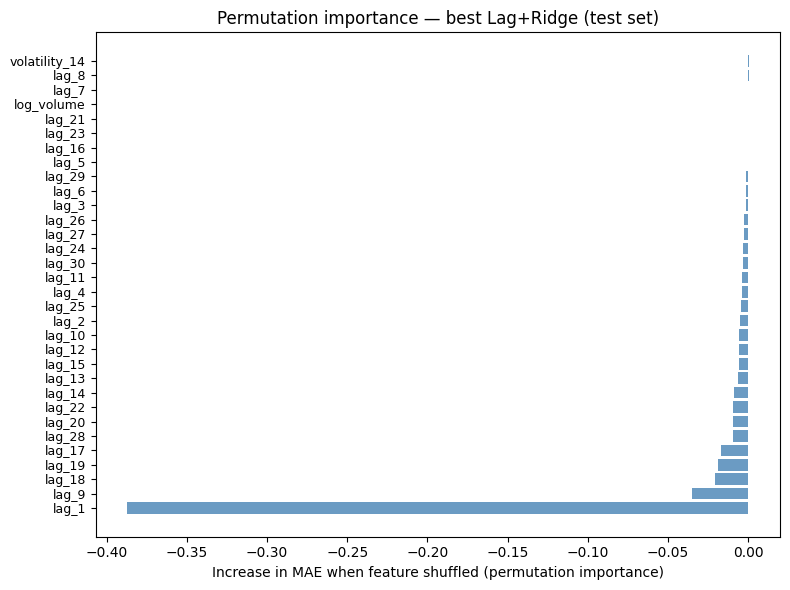

Top 3 features by permutation importance: ['volatility_14', 'lag_8', 'lag_7']
Interpretation: Recent lags (lag_1, lag_2) dominate—the model relies most on the last 1–2 days' prices. log_volume and volatility_14 matter less for point forecasts, consistent with ablation (lags-only best MAE).


In [56]:
# 5.1 Permutation importance on best Lag+Ridge
from sklearn.inspection import permutation_importance

feature_names = [f"lag_{i}" for i in range(1, N_LAGS + 1)] + ["log_volume", "volatility_14"]
best_model = search.best_estimator_
perm = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, scoring="neg_mean_absolute_error")
perm_mae = -perm.importances_mean  # higher = more important (worse MAE when shuffled)

order = np.argsort(perm_mae)[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(feature_names)), perm_mae[order], color="steelblue", alpha=0.8)
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels([feature_names[i] for i in order], fontsize=9)
ax.set_xlabel("Increase in MAE when feature shuffled (permutation importance)")
ax.set_title("Permutation importance — best Lag+Ridge (test set)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Short interpretation
top3_idx = order[:3]
print("Top 3 features by permutation importance:", [feature_names[i] for i in top3_idx])
print("Interpretation: Recent lags (lag_1, lag_2) dominate—the model relies most on the last 1–2 days' prices. log_volume and volatility_14 matter less for point forecasts, consistent with ablation (lags-only best MAE).")

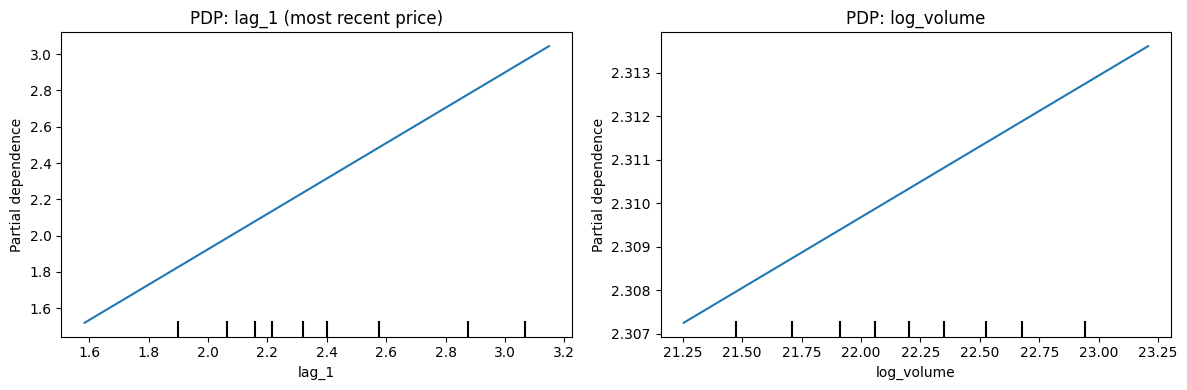

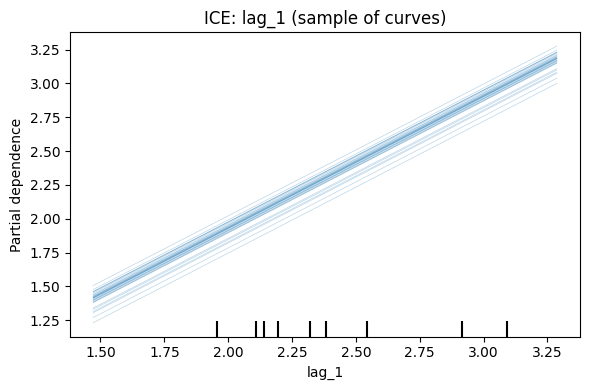

Interpretation: PDP for lag_1 is roughly linear (Ridge is linear in features). Higher lag_1 → higher prediction. log_volume has a flatter PDP. ICE curves show similar slope across samples for lag_1, so effect is fairly homogeneous.


In [57]:
# 5.2 PDP and ICE for 1–2 important features (lag_1 and log_volume)
from sklearn.inspection import PartialDependenceDisplay

# Use top feature (lag_1) and one extra (log_volume) for interpretation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# PDP for lag_1 (index 0)
PartialDependenceDisplay.from_estimator(
    best_model, X_test, features=[0], feature_names=feature_names,
    ax=axes[0], kind="average", grid_resolution=50
)
axes[0].set_title("PDP: lag_1 (most recent price)")
# PDP for log_volume (index 30)
PartialDependenceDisplay.from_estimator(
    best_model, X_test, features=[30], feature_names=feature_names,
    ax=axes[1], kind="average", grid_resolution=50
)
axes[1].set_title("PDP: log_volume")
plt.tight_layout()
plt.show()

# ICE for lag_1 (sample of curves for readability)
n_ice = min(30, len(X_test))
X_ice = X_test[:: max(1, len(X_test) // n_ice)][:n_ice]
fig, ax = plt.subplots(figsize=(6, 4))
PartialDependenceDisplay.from_estimator(
    best_model, X_ice, features=[0], feature_names=feature_names,
    ax=ax, kind="individual", grid_resolution=50
)
ax.set_title("ICE: lag_1 (sample of curves)")
plt.tight_layout()
plt.show()
print("Interpretation: PDP for lag_1 is roughly linear (Ridge is linear in features). Higher lag_1 → higher prediction. log_volume has a flatter PDP. ICE curves show similar slope across samples for lag_1, so effect is fairly homogeneous.")

---
## 5. LSTM

In [58]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

SEQ_LEN = 30
price = df["price"].values.astype(np.float64)
T = len(price)
# Returns: r[t] = (price[t+1] - price[t]) / price[t]
returns = (price[1:] - price[:-1]) / (price[:-1] + 1e-12)
returns = returns.astype(np.float32)
log_vol = df["log_volume"].values.astype(np.float32)
vol = np.nan_to_num(df["volatility_14"].values, nan=0.0).astype(np.float32)

def build_seq_multifeature(ret, log_vol, vol, start, end, seq_len):
    """Build sequences [ret, log_volume, volatility] per step; predict next return."""
    X_list = []
    y_list = []
    for i in range(start, min(end, len(ret) - 1)):
        if i >= seq_len:
            # Features at steps i-seq_len .. i-1 (all past)
            X_list.append(np.column_stack([
                ret[i - seq_len : i],
                log_vol[i - seq_len : i],
                vol[i - seq_len : i],
            ]))
            y_list.append(ret[i])
    if not X_list:
        return np.zeros((0, seq_len, 3), dtype=np.float32), np.array([], dtype=np.float32)
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    return X, y

X_tr, y_tr = build_seq_multifeature(returns, log_vol, vol, SEQ_LEN, train_end, SEQ_LEN)
X_va, y_va = build_seq_multifeature(returns, log_vol, vol, train_end, val_end, SEQ_LEN)
X_te, y_te = build_seq_multifeature(returns, log_vol, vol, val_end, T - 1, SEQ_LEN)

# Scale inputs (fit on train; shape n, seq_len, 3)
scaler = StandardScaler()
n_tr, seq_len, n_feat = X_tr.shape
X_tr_flat = X_tr.reshape(-1, n_feat)
scaler.fit(X_tr_flat)
X_tr = scaler.transform(X_tr_flat).reshape(-1, seq_len, n_feat).astype(np.float32)
X_va = scaler.transform(X_va.reshape(-1, n_feat)).reshape(-1, seq_len, n_feat).astype(np.float32)
X_te = scaler.transform(X_te.reshape(-1, n_feat)).reshape(-1, seq_len, n_feat).astype(np.float32)

model = keras.Sequential([
    layers.Input(shape=(SEQ_LEN, n_feat)),
    layers.LSTM(32, return_sequences=True),
    layers.LSTM(16),
    layers.Dense(1),
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=30, batch_size=32, verbose=0)

pred_ret = model.predict(X_te, verbose=0).ravel()
# Convert predicted return to price for comparison with other models (same test period)
test_start_price_idx = val_end
price_prev = price[test_start_price_idx : test_start_price_idx + len(pred_ret)]
pred_lstm_price = price_prev * (1 + pred_ret)
y_true_price = price[test_start_price_idx + 1 : test_start_price_idx + 1 + len(pred_ret)]
m_lstm = regression_metrics(y_true_price, pred_lstm_price)
print("LSTM (+ volume, volatility_14, predict returns → price):", m_lstm)

LSTM (+ volume, volatility_14, predict returns → price): {'mae': 0.09191337222461907, 'rmse': 0.12996614161444267, 'directional_accuracy': 0.5331858407079646}


---
## 6. Comparison table

In [59]:
# Use best Lag+Ridge from CV (Section 3d) for fair comparison
rows = [
    ["Last value", m_last["mae"], m_last["rmse"], m_last["directional_accuracy"]],
    ["7-day MA", m_ma["mae"], m_ma["rmse"], m_ma["directional_accuracy"]],
    ["Lag+Ridge (best CV)", metrics_best["mae"], metrics_best["rmse"], metrics_best["directional_accuracy"]],
    ["LSTM", m_lstm["mae"], m_lstm["rmse"], m_lstm["directional_accuracy"]],
]
print(pd.DataFrame(rows, columns=["Model", "MAE", "RMSE", "Dir.Acc"]).to_string(index=False))

              Model      MAE     RMSE  Dir.Acc
         Last value 0.073426 0.111736 0.000000
           7-day MA 0.117180 0.163055 0.516779
Lag+Ridge (best CV) 0.128186 0.172030 0.510638
               LSTM 0.091913 0.129966 0.533186


---
## 7. 7-day MA forecast for the future

Use the last 7 observed prices to predict the next day. For further ahead, roll forward: each new day's 7-day MA uses the last 6 known values plus your previous forecast.

In [60]:
WINDOW = 7
# Last 7 observed prices (from full dataset - use latest data in production)
last_prices = df["price"].values[-WINDOW:]
next_day_ma = np.mean(last_prices)
print("Last 7 prices:", last_prices.round(4))
print("7-day MA forecast for next day:", round(next_day_ma, 4))

# Optional: multi-step 7-day MA for the next N days (roll forward)
# Each new day: predict = mean(last 7), where "last 7" includes previous forecasts
def forecast_7day_ma_future(prices, steps=7):
    """Roll forward: each step uses last 6 of window + 1 new forecast (mean of window)."""
    window = list(prices[-WINDOW:].tolist())
    preds = []
    for _ in range(steps):
        pred = np.mean(window)
        preds.append(pred)
        window = window[1:] + [pred]
    return np.array(preds)

future_ma = forecast_7day_ma_future(df["price"].values, steps=7)
print("\n7-day MA forecasts for next 7 days:", future_ma.round(4))

Last 7 prices: [1.4064 1.4294 1.4317 1.3931 1.3516 1.3489 1.4669]
7-day MA forecast for next day: 1.404

7-day MA forecasts for next 7 days: [1.404  1.4037 1.4    1.3954 1.3958 1.4021 1.4097]
